# 9. Reducción de dimensionalidad y creación de índices comerciales

El objetivo de este notebook es transformar muchas variables dispersas en índices sint?ticos ?tiles para decisión inmobiliaria. En el caso de negocio flipper, el exceso de variables de amenities, distancias y atributos f?sicos puede dificultar la lectura r?pida de oportunidades.

Se aplican dos técnicas:

- **PCA** para variables continuas de entorno urbano y amplitud de la propiedad.
- **MCA** para variables categóricas/binarias, especialmente amenities.

Los índices finales se escalan de 0 a 100 para facilitar gráficos, comparación entre barrios, segmentación por cluster y uso posterior en modelos de tasación o priorización de oportunidades.


## Criterio de seleccion de componentes

Para PCA se usa la **regla de Kaiser**: conservar componentes con autovalor mayor a 1. Como las variables se estandarizan, un autovalor mayor a 1 indica que el componente explica mas varianza que una variable original promedio.

Para MCA no se aplica Kaiser en sentido estricto, porque MCA trabaja con inercia sobre una matriz indicadora/categorica. En ese caso se reporta la inercia explicada y se elige el componente que tenga interpretacion comercial clara para construir el indice de amenities.

In [1]:
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import prince
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

INPUT_PATH = "Argenprop_limpio.csv"
OUTPUT_PATH = "Argenprop_limpio_con_indices.csv"

df = pd.read_csv(INPUT_PATH, encoding="utf-8-sig")
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
df.head()

Dataset cargado: 7,245 filas x 55 columnas


,sintetica_id_registro,imputada_Precio,imputada_Expensas,original_Calle,original_Altura,imputada_Piso,original_Link,imputada_Ambientes,imputada_Dormitorios,original_Banos,imputada_Estado,imputada_Antiguedad,imputada_Disposicion,imputada_Tipo_Unidad,imputada_Sup_Cubierta_m2,imputada_Sup_Total_m2,sintetica_Aire_acondicionado_individual,sintetica_Losa_radiante,sintetica_Gas_natural,sintetica_Agua_corriente,sintetica_Balcon,sintetica_Terraza,sintetica_Jardin,sintetica_Patio,sintetica_Baulera,sintetica_Cochera,sintetica_Muebles_de_cocina,sintetica_Permite_Mascotas,sintetica_Ascensor,sintetica_Pileta,sintetica_Parrilla,sintetica_Gimnasio,sintetica_Sauna,sintetica_Laundry,sintetica_Vigilancia,enriquecida_Latitud,enriquecida_Longitud,enriquecida_Barrio,enriquecida_Comuna,enriquecida_Dist_Subte_m,enriquecida_Subte_cercano,enriquecida_Linea_subte,enriquecida_Dist_Hospital_m,enriquecida_Hospital_cercano,enriquecida_Dist_Colegio_m,enriquecida_Colegios_500m,enriquecida_Dist_Comisaria_m,enriquecida_Dist_Gimnasio_m,enriquecida_Dist_Supermercado_m,enriquecida_Supermercados_500m,enriquecida_Dist_Avenida_m,enriquecida_Avenida_cercana,enriquecida_Paradas_colectivo_300m,imputada_Antiguedad_imputada,sintetica_Cluster
0,1,"150,000.0000","260,000.0000",Bulnes,"1,600.0000",No disponible,https://www.argenprop.com/departamento-en-vent...,3,2,1.0000,Excelente,30,Frente,Departamento,60.0000,60.0000,1,0,1,1,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,-34.5868,-58.4107,Palermo,14,167.7761,BULNES,D,719.1936,Dr. J. A. Fernandez,180.3531,10,493.1267,51.7275,20.2793,10,156.7883,Avenida Santa Fe,19,0,4
1,2,"330,000.0000","203,300.0000",ARAOZ,"1,200.0000",8,https://www.argenprop.com/departamento-en-vent...,4,3,2.0000,Bueno,50,Contrafrente,No disponible,90.0000,96.0000,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,-34.5889,-58.4202,Palermo,14,563.7326,R.SCALABRINI ORTIZ,D,948.6219,R. Gutierrez,188.5377,11,403.1148,429.5844,249.2481,4,96.5150,Avenida Raúl Scalabrini Ortiz,10,1,4
2,3,"270,000.0000","300,000.0000",Honduras,"3,900.0000",2,https://www.argenprop.com/departamento-en-vent...,4,2,2.0000,Excelente,20,Frente,Semipiso,87.0000,87.0000,1,0,1,1,1,1,0,0,0,1,1,0,1,0,0,0,0,0,0,-34.5813,-58.4400,Palermo,14,815.4656,MINISTRO CARRANZA - MIGUEL ABUELO,D,"2,930.4049",Hospital Municipal de Oncologia M. Curie,240.8739,7,891.1453,383.0179,75.2437,7,425.4954,Avenida Coronel Niceto Vega,5,0,4
3,4,"570,000.0000","1,000,000.0000",Castex,"3,300.0000",No disponible,https://www.argenprop.com/departamento-en-vent...,4,3,3.0000,No disponible,40,No disponible,Piso,140.0000,160.0000,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,-34.5761,-58.4076,Palermo,14,"1,262.2533",R.SCALABRINI ORTIZ,D,559.8688,Dr. J. A. Fernandez,256.7976,4,804.1383,286.6980,217.0756,3,108.4441,Avenida Casares,7,0,4
4,5,"98,000.0000","150,000.0000",GURRUCHAGA,"2,100.0000",5,https://www.argenprop.com/departamento-en-vent...,1,1,1.0000,Muy Bueno,15,Frente,No disponible,31.0000,34.0000,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,-34.5883,-58.4277,Palermo,14,973.2733,PLAZA ITALIA,D,"1,574.5700",R. Gutierrez,153.6102,5,461.4835,393.5680,85.2867,6,378.8029,Avenida Raúl Scalabrini Ortiz,7,0,4


## Utilidades y mapa de columnas

El dataset final tiene prefijos (`imputada_`, `sintetica_`, `enriquecida_`, `original_`). Para escribir codigo legible, se arma un mapa que permite llamar columnas por su nombre conceptual.

In [2]:
def normalizar_nombre(nombre):
    nombre = unicodedata.normalize("NFKD", str(nombre))
    nombre = nombre.encode("ascii", "ignore").decode("ascii")
    nombre = re.sub(r"[^0-9A-Za-z_]+", "_", nombre)
    nombre = re.sub(r"_+", "_", nombre).strip("_")
    return nombre

columnas_por_base = {}
for columna in df.columns:
    partes = str(columna).split("_", 1)
    base = partes[1] if partes[0] in {"original", "imputada", "sintetica", "enriquecida"} and len(partes) > 1 else str(columna)
    columnas_por_base[normalizar_nombre(base)] = columna

def c(nombre):
    key = normalizar_nombre(nombre)
    if key not in columnas_por_base:
        raise KeyError(f"No se encontro columna conceptual: {nombre}")
    return columnas_por_base[key]

def minmax_0_100(series):
    s = pd.Series(series, index=df.index) if not isinstance(series, pd.Series) else series
    s = pd.to_numeric(s, errors="coerce")
    values = s.to_numpy().reshape(-1, 1)
    return pd.Series(MinMaxScaler().fit_transform(values).ravel() * 100, index=s.index)

def inv_score(series):
    s = pd.to_numeric(series, errors="coerce")
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    denom = hi - lo
    if pd.isna(denom) or denom == 0:
        return pd.Series(0, index=s.index)
    clipped = s.clip(lo, hi)
    return (1 - (clipped - lo) / denom).clip(0, 1).fillna(0)

def orientar_componente(scores, referencia):
    corr = np.corrcoef(pd.Series(scores).fillna(0), pd.Series(referencia).fillna(0))[0, 1]
    return -scores if corr < 0 else scores

def correr_pca(dataframe, nombre):
    scaler = StandardScaler()
    X = scaler.fit_transform(dataframe)
    pca = PCA().fit(X)
    eigenvalues = pca.explained_variance_
    n_kaiser = max(1, int((eigenvalues > 1).sum()))
    scores = pca.transform(X)[:, :n_kaiser]
    loadings = pd.DataFrame(
        pca.components_[:n_kaiser].T,
        index=dataframe.columns,
        columns=[f"PC{i+1}" for i in range(n_kaiser)]
    )
    resumen = pd.DataFrame({
        "componente": [f"PC{i+1}" for i in range(len(eigenvalues))],
        "autovalor": eigenvalues,
        "varianza_explicada": pca.explained_variance_ratio_,
        "varianza_acumulada": np.cumsum(pca.explained_variance_ratio_),
        "conservar_kaiser": eigenvalues > 1
    })
    print(f"{nombre}: se conservan {n_kaiser} componente(s) por Kaiser (autovalor > 1).")
    return pca, scores, loadings, resumen


## 1. PCA de entorno urbano

Las distancias se transforman para que valores mas altos impliquen mayor cercania. Luego se combinan con conteos de servicios cercanos. El objetivo comercial es sintetizar muchas variables de ubicacion en indices de entorno.

In [3]:
entorno = pd.DataFrame({
    "cercania_subte": inv_score(df[c("Dist_Subte_m")]),
    "cercania_hospital": inv_score(df[c("Dist_Hospital_m")]),
    "cercania_colegio": inv_score(df[c("Dist_Colegio_m")]),
    "cercania_comisaria": inv_score(df[c("Dist_Comisaria_m")]),
    "cercania_gimnasio": inv_score(df[c("Dist_Gimnasio_m")]),
    "cercania_supermercado": inv_score(df[c("Dist_Supermercado_m")]),
    "cercania_avenida": inv_score(df[c("Dist_Avenida_m")]),
    "colegios_500m": (df[c("Colegios_500m")] / df[c("Colegios_500m")].quantile(0.99)).clip(0, 1),
    "supermercados_500m": (df[c("Supermercados_500m")] / df[c("Supermercados_500m")].quantile(0.99)).clip(0, 1),
    "colectivos_300m": (df[c("Paradas_colectivo_300m")] / df[c("Paradas_colectivo_300m")].quantile(0.99)).clip(0, 1),
}).fillna(0)

pca_entorno, scores_entorno, loadings_entorno, resumen_entorno = correr_pca(entorno, "PCA entorno urbano")
display(resumen_entorno)
display(loadings_entorno.round(3))

PCA entorno urbano: se conservan 3 componente(s) por Kaiser (autovalor > 1).


,componente,autovalor,varianza_explicada,varianza_acumulada,conservar_kaiser
0,PC1,3.2779,0.3277,0.3277,True
1,PC2,1.6225,0.1622,0.4900,True
2,PC3,1.0474,0.1047,0.5947,True
3,PC4,0.8893,0.0889,0.6836,False
4,PC5,0.7511,0.0751,0.7587,False
5,PC6,0.6277,0.0628,0.8215,False
6,PC7,0.5643,0.0564,0.8779,False
7,PC8,0.5222,0.0522,0.9301,False
8,PC9,0.3767,0.0377,0.9678,False
9,PC10,0.3223,0.0322,1.0000,False


,PC1,PC2,PC3
cercania_subte,0.3970,-0.0470,0.0560
cercania_hospital,0.0680,-0.2420,0.8010
cercania_colegio,0.3400,-0.2260,0.1810
cercania_comisaria,0.2300,-0.3780,-0.4310
cercania_gimnasio,0.2440,0.5010,0.1840
cercania_supermercado,0.3340,0.4300,-0.1180
cercania_avenida,0.2750,-0.2980,-0.1560
colegios_500m,0.3810,-0.2520,0.1610
supermercados_500m,0.3860,0.3820,0.0180
colectivos_300m,0.3580,-0.1040,-0.1940


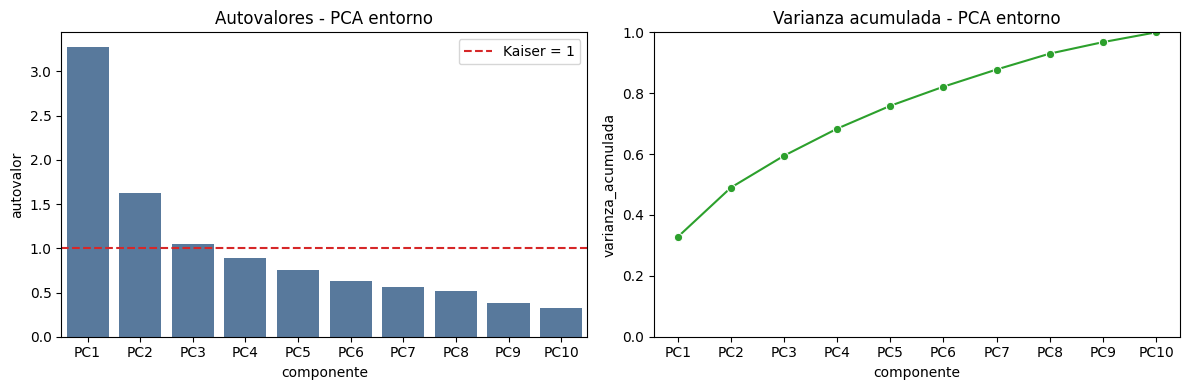

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=resumen_entorno, x="componente", y="autovalor", ax=axes[0], color="#4C78A8")
axes[0].axhline(1, color="#D62728", linestyle="--", label="Kaiser = 1")
axes[0].set_title("Autovalores - PCA entorno")
axes[0].legend()

sns.lineplot(data=resumen_entorno, x="componente", y="varianza_acumulada", marker="o", ax=axes[1], color="#2CA02C")
axes[1].set_ylim(0, 1)
axes[1].set_title("Varianza acumulada - PCA entorno")
plt.tight_layout()
plt.show()

### Indices de entorno resultantes

Segun Kaiser, el PCA de entorno conserva 3 componentes. Para que sean usables comercialmente, se escalan de 0 a 100 y se nombran segun sus cargas principales.

In [5]:
df_indices = df.copy()

referencia_entorno = entorno.mean(axis=1)
df_indices["indice_entorno_integral_pca"] = minmax_0_100(orientar_componente(scores_entorno[:, 0], referencia_entorno))

if scores_entorno.shape[1] >= 2:
    df_indices["indice_servicios_barriales_pca"] = minmax_0_100(scores_entorno[:, 1])

if scores_entorno.shape[1] >= 3:
    df_indices["indice_conectividad_pca"] = minmax_0_100(scores_entorno[:, 2])

df_indices[[col for col in df_indices.columns if col.startswith("indice_")]].describe().T

,count,mean,std,min,25%,50%,75%,max
indice_entorno_integral_pca,"7,245.0000",62.3617,17.2035,0.0000,50.6924,65.3588,75.1249,100.0000
indice_servicios_barriales_pca,"7,245.0000",58.0939,18.0032,0.0000,47.0432,58.8234,70.9405,100.0000
indice_conectividad_pca,"7,245.0000",51.8527,14.4917,0.0000,43.2086,53.1859,61.8475,100.0000


## 2. PCA de amplitud de la propiedad

Este PCA resume superficie, ambientes, dormitorios y baños. El objetivo comercial es obtener un indice de escala/amplitud de la unidad.

In [6]:
variables_amplitud = [
    c("Sup_Cubierta_m2"), c("Sup_Total_m2"), c("Ambientes"), c("Dormitorios"), c("Banos")
]

amplitud = df[variables_amplitud].apply(pd.to_numeric, errors="coerce")
amplitud = amplitud.fillna(amplitud.median(numeric_only=True))
amplitud.columns = ["sup_cubierta", "sup_total", "ambientes", "dormitorios", "banos"]

pca_amplitud, scores_amplitud, loadings_amplitud, resumen_amplitud = correr_pca(amplitud, "PCA amplitud")
display(resumen_amplitud)
display(loadings_amplitud.round(3))

PCA amplitud: se conservan 1 componente(s) por Kaiser (autovalor > 1).


,componente,autovalor,varianza_explicada,varianza_acumulada,conservar_kaiser
0,PC1,4.0584,0.8116,0.8116,True
1,PC2,0.5100,0.1020,0.9135,False
2,PC3,0.3014,0.0603,0.9738,False
3,PC4,0.0843,0.0169,0.9907,False
4,PC5,0.0467,0.0093,1.0000,False


,PC1
sup_cubierta,0.4720
sup_total,0.4640
ambientes,0.4530
dormitorios,0.4490
banos,0.3940


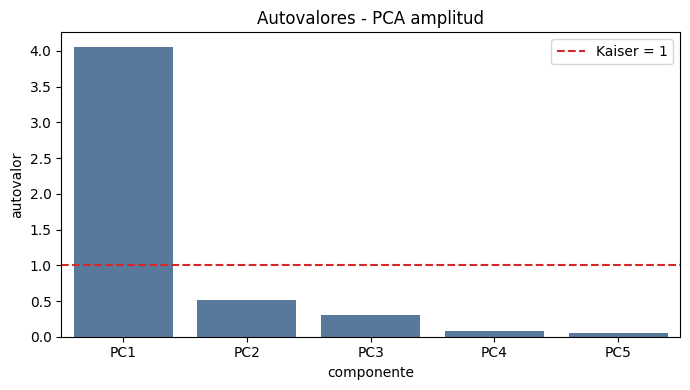

,count,mean,std,min,25%,50%,75%,max
indice_amplitud_pca,"7,245.0000",17.7731,14.1587,0.0000,6.9954,15.3698,24.6278,100.0000


In [7]:
referencia_amplitud = amplitud[["sup_total", "ambientes", "dormitorios", "banos"]].mean(axis=1)
df_indices["indice_amplitud_pca"] = minmax_0_100(orientar_componente(scores_amplitud[:, 0], referencia_amplitud))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=resumen_amplitud, x="componente", y="autovalor", ax=ax, color="#4C78A8")
ax.axhline(1, color="#D62728", linestyle="--", label="Kaiser = 1")
ax.set_title("Autovalores - PCA amplitud")
ax.legend()
plt.tight_layout()
plt.show()

df_indices[["indice_amplitud_pca"]].describe().T

## 3. MCA de amenities

Los amenities son variables binarias/categoricas. MCA permite sintetizar patrones de presencia/ausencia en dimensiones latentes. Se usa la primera dimension como indice de lujo/confort cuando su direccion se alinea con mayor dotacion de amenities.

In [8]:
amenities_base = [
    "Aire_acondicionado_individual", "Losa_radiante", "Gas_natural", "Agua_corriente",
    "Balcon", "Terraza", "Jardin", "Patio", "Baulera", "Cochera",
    "Muebles_de_cocina", "Permite_Mascotas", "Ascensor", "Pileta", "Parrilla",
    "Gimnasio", "Sauna", "Laundry", "Vigilancia"
]
amenity_cols = [c(nombre) for nombre in amenities_base if normalizar_nombre(nombre) in columnas_por_base]

amenities = df[amenity_cols].fillna(0).astype(int)
cantidad_amenities = amenities.sum(axis=1)

amenities_mca = amenities.astype(str)
mca = prince.MCA(n_components=4, random_state=42)
coords_mca = mca.fit_transform(amenities_mca)

mca_resumen = pd.DataFrame({
    "dimension": [f"Dim{i+1}" for i in range(coords_mca.shape[1])],
    "autovalor_inercia": mca.eigenvalues_,
    "porcentaje_inercia": mca.percentage_of_variance_,
    "porcentaje_acumulado": np.cumsum(mca.percentage_of_variance_)
})

display(mca_resumen)
coords_mca.head()

,dimension,autovalor_inercia,porcentaje_inercia,porcentaje_acumulado
0,Dim1,0.1503,15.0317,15.0317
1,Dim2,0.1098,10.9772,26.0088
2,Dim3,0.0915,9.1537,35.1625
3,Dim4,0.0742,7.4225,42.5850


,0,1,2,3
0,0.4886,-0.6724,0.1707,-0.3766
1,0.3133,0.1082,-0.2855,0.5341
2,0.6193,-0.5901,0.0447,-0.3597
3,0.0557,-0.0353,-0.3051,-0.1368
4,0.0275,0.1079,0.1866,0.1381


Correlacion indice_lujo_confort_mca vs cantidad de amenities: 0.934


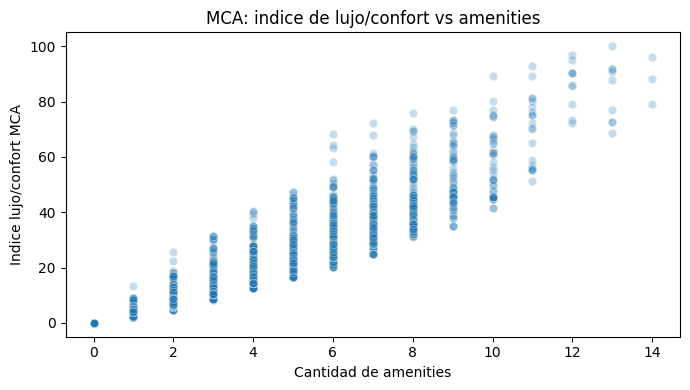

In [9]:
dim_lujo = coords_mca.iloc[:, 0]
dim_lujo = orientar_componente(dim_lujo, cantidad_amenities)

df_indices["indice_lujo_confort_mca"] = minmax_0_100(dim_lujo)
df_indices["cantidad_amenities"] = cantidad_amenities

print("Correlacion indice_lujo_confort_mca vs cantidad de amenities:", np.corrcoef(df_indices["indice_lujo_confort_mca"], cantidad_amenities)[0, 1].round(3))

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x=cantidad_amenities, y=df_indices["indice_lujo_confort_mca"], alpha=0.25, ax=ax)
ax.set_xlabel("Cantidad de amenities")
ax.set_ylabel("Indice lujo/confort MCA")
ax.set_title("MCA: indice de lujo/confort vs amenities")
plt.tight_layout()
plt.show()

## 4. Score de antiguedad

La antiguedad es una variable individual, por lo que no necesita PCA. Se crea un score simple de 0 a 100 donde valores mas altos representan unidades mas nuevas.

In [10]:
antiguedad = pd.to_numeric(df[c("Antiguedad")], errors="coerce")
antiguedad_clip = antiguedad.clip(antiguedad.quantile(0.01), antiguedad.quantile(0.99))
df_indices["score_antiguedad_nueva"] = 100 - minmax_0_100(antiguedad_clip)

df_indices[["score_antiguedad_nueva"]].describe().T

,count,mean,std,min,25%,50%,75%,max
score_antiguedad_nueva,"7,245.0000",59.2301,21.5145,0.0000,45.9770,57.4713,80.4598,100.0000


## 5. Validacion comercial de indices

Se revisa si los indices sinteticos se relacionan con precio, precio por m2 y cluster. Esto no prueba causalidad, pero ayuda a validar si los indices agregan lectura comercial.

In [11]:
df_indices["precio_m2"] = df_indices[c("Precio")] / df_indices[c("Sup_Total_m2")]

indices_creados = [
    "indice_entorno_integral_pca",
    "indice_servicios_barriales_pca",
    "indice_conectividad_pca",
    "indice_amplitud_pca",
    "indice_lujo_confort_mca",
    "score_antiguedad_nueva"
]
indices_creados = [col for col in indices_creados if col in df_indices.columns]

correlaciones = df_indices[indices_creados + [c("Precio"), "precio_m2"]].corr(numeric_only=True)[[c("Precio"), "precio_m2"]].loc[indices_creados]
correlaciones.round(3)

,imputada_Precio,precio_m2
indice_entorno_integral_pca,-0.0090,-0.0030
indice_servicios_barriales_pca,0.1930,0.3080
indice_conectividad_pca,-0.0570,-0.0570
indice_amplitud_pca,0.7230,-0.0110
indice_lujo_confort_mca,0.2490,0.2850
score_antiguedad_nueva,0.0580,0.3430


,indice_entorno_integral_pca,indice_servicios_barriales_pca,indice_conectividad_pca,indice_amplitud_pca,indice_lujo_confort_mca,score_antiguedad_nueva,precio_m2
sintetica_Cluster,,,,,,,
0,66.5500,51.4700,60.2800,9.4900,10.6100,51.7200,"1,775.3500"
1,54.0100,65.2100,48.6500,14.0300,11.8900,68.9700,"2,281.9700"
2,78.4300,62.1900,53.0900,19.2300,10.7800,45.9800,"2,315.1300"
3,33.0300,77.1000,31.2300,27.1500,26.6500,87.3600,"4,785.8200"
4,60.8000,60.5800,54.7200,16.1600,12.3700,57.4700,"2,360.0000"
5,75.5000,46.6200,49.5200,14.9400,9.0500,45.9800,"1,700.0000"


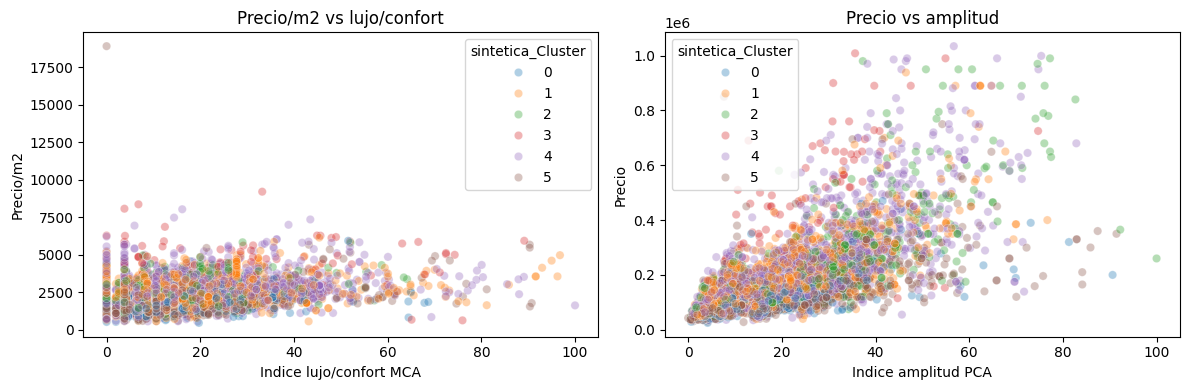

In [12]:
cluster_col = c("Cluster") if normalizar_nombre("Cluster") in columnas_por_base else None

if cluster_col:
    resumen_cluster = (
        df_indices.groupby(cluster_col)[indices_creados + ["precio_m2"]]
        .median()
        .round(2)
    )
    display(resumen_cluster)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df_indices, x="indice_lujo_confort_mca", y="precio_m2", hue=cluster_col, alpha=0.35, ax=axes[0], palette="tab10")
axes[0].set_title("Precio/m2 vs lujo/confort")
axes[0].set_xlabel("Indice lujo/confort MCA")
axes[0].set_ylabel("Precio/m2")

sns.scatterplot(data=df_indices, x="indice_amplitud_pca", y=c("Precio"), hue=cluster_col, alpha=0.35, ax=axes[1], palette="tab10")
axes[1].set_title("Precio vs amplitud")
axes[1].set_xlabel("Indice amplitud PCA")
axes[1].set_ylabel("Precio")
plt.tight_layout()
plt.show()

## 6. Guardado de dataset con indices

Se guarda una version nueva para no pisar el dataset limpio base.

In [13]:
df_indices.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"Archivo generado: {OUTPUT_PATH}")
print("Shape:", df_indices.shape)
print("Indices creados:")
for col in indices_creados:
    print("-", col)

Archivo generado: Argenprop_limpio_con_indices.csv
Shape: (7245, 63)
Indices creados:
- indice_entorno_integral_pca
- indice_servicios_barriales_pca
- indice_conectividad_pca
- indice_amplitud_pca
- indice_lujo_confort_mca
- score_antiguedad_nueva


## Interpretacion final

- **PCA entorno urbano:** la regla de Kaiser conserva los componentes con autovalor > 1. El primer indice resume intensidad general de entorno/accesibilidad; los siguientes capturan diferencias mas especificas entre servicios barriales y conectividad.
- **PCA amplitud:** Kaiser conserva un solo componente, interpretable como escala o amplitud de la propiedad.
- **MCA amenities:** la primera dimension se orienta para que valores altos indiquen mayor dotacion de amenities, creando un indice de lujo/confort.
- **Score de antiguedad:** transforma antiguedad en una escala directa de 0 a 100, donde mayor valor implica unidad mas nueva.

Estos indices reducen variables dispersas a scores sinteticos aptos para graficos, comparacion entre barrios, segmentacion por cluster y modelos de tasacion.